# Singular Value Decomposition (SVD)

This notebook investigates the computational behavior of singular value decomposition, with emphasis on numerical rank, conditioning, pseudoinverses, low-rank approximation, and principal component analysis. A from-scratch eigendecomposition route is compared with a direct SVD implementation to expose the stability cost of forming $A^TA$.

## Experimental Scope

The notebook evaluates the following components:

1. the dimensions and geometric interpretation of $A = U\Sigma V^T$;
2. an SVD implementation based on the eigendecomposition of $A^T A$;
3. reconstruction, orthogonality, and numerical-rank diagnostics;
4. construction of the Moore–Penrose pseudoinverse;
5. minimum-norm least-squares solutions;
6. optimal low-rank approximation and singular-value energy;
7. principal component analysis (PCA);
8. sensitivity to increasing matrix condition numbers.

## 1. Setup

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
rng = np.random.default_rng(42)

## 2. Definition and Matrix Shapes

For a matrix $A \in \mathbb{R}^{m \times n}$, the full SVD is

$$A = U\Sigma V^T,$$

where:

- $U \in \mathbb{R}^{m \times m}$ has orthonormal columns (left singular vectors),
- $V \in \mathbb{R}^{n \times n}$ has orthonormal columns (right singular vectors),
- $\Sigma \in \mathbb{R}^{m \times n}$ contains nonnegative singular values in descending order.

For the reduced SVD, let $r = \min(m,n)$. Then $U_r$ is $m \times r$, $\Sigma_r$ is $r \times r$, and $V_r^T$ is $r \times n$.

In [2]:
# A rectangular example matrix
A = np.array([
    [3.0, 1.0, 1.0],
    [-1.0, 3.0, 1.0],
    [0.0, 2.0, 4.0],
    [1.0, 0.0, 2.0],
])

m, n = A.shape
print("A shape:", A.shape)
print("Reduced factor shapes should be:", (m, min(m, n)), (min(m, n),), (min(m, n), n))

A shape: (4, 3)
Reduced factor shapes should be: (4, 3) (3,) (3, 3)


## 3. Geometric Interpretation

The transformation $Ax$ can be viewed as three successive operations:

$$x \xrightarrow{V^T} V^Tx \xrightarrow{\Sigma} \Sigma V^Tx \xrightarrow{U} U\Sigma V^Tx.$$

$V^T$ rotates or reflects the input coordinates, $\Sigma$ stretches along orthogonal directions, and $U$ rotates or reflects the result.

## 4. Relationship with Eigenvalues and Eigenvectors

Starting from $A = U\Sigma V^T$,

$$A^TA = V\Sigma^T\Sigma V^T.$$

Therefore, the columns of $V$ are eigenvectors of $A^TA$, and

$$\sigma_i = \sqrt{\lambda_i(A^TA)}.$$

For every nonzero singular value, the corresponding left singular vector is

$$u_i = \frac{Av_i}{\sigma_i}.$$

> This construction is included as a controlled stability experiment. Production numerical software generally avoids forming $A^TA$ because doing so squares the condition number and degrades information in the smallest singular directions.

In [3]:
gram_matrix = A.T @ A
eigenvalues, eigenvectors = np.linalg.eigh(gram_matrix)

# np.linalg.eigh returns eigenvalues in ascending order.
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Tiny negative eigenvalues may appear because of floating-point roundoff.
eigenvalues = np.clip(eigenvalues, 0.0, None)
singular_values_from_eigenvalues = np.sqrt(eigenvalues)

print("A.T @ A =\n", gram_matrix)
print("\nEigenvalues =", eigenvalues)
print("Singular values =", singular_values_from_eigenvalues)

A.T @ A =
 [[11.  0.  4.]
 [ 0. 14. 12.]
 [ 4. 12. 22.]]

Eigenvalues = [31.176532 11.363746  4.459722]
Singular values = [5.583595 3.371016 2.111805]


## 5. SVD via Eigendecomposition

The from-scratch reduced SVD follows this computational pipeline:

1. Convert the input to a floating-point array.
2. Compute the eigenpairs of $A^TA$.
3. Sort the eigenvalues and eigenvectors in descending order.
4. Clip tiny negative eigenvalues caused by roundoff.
5. Compute the singular values.
6. Determine numerical rank using a tolerance.
7. Compute nonzero left singular vectors using $u_i = Av_i/\sigma_i$.

The implementation returns the components associated with singular values above a numerical tolerance. This makes the loss of small singular directions explicit when $A^TA$ becomes numerically rank deficient.

In [4]:
def svd_via_eigendecomposition(A, tol=None):
    """
    Compute a reduced SVD through the eigendecomposition of A.T @ A.

    Parameters
    ----------
    A : array_like, shape (m, n)
        Input matrix.
    tol : float or None
        Threshold used to identify nonzero singular values.

    Returns
    -------
    U : ndarray, shape (m, r)
    s : ndarray, shape (r,)
    Vt : ndarray, shape (r, n)
        Here r is the numerical rank.
    """
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")
    if min(A.shape) == 0:
        raise ValueError("A must not have an empty dimension.")
    if not np.all(np.isfinite(A)):
        raise ValueError("A must contain only finite values.")

    m, n = A.shape
    eigenvalues, V = np.linalg.eigh(A.T @ A)

    # Sort the eigenpairs from the largest eigenvalue to the smallest.
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    V = V[:, order]

    eigenvalues = np.clip(eigenvalues, 0.0, None)
    s = np.sqrt(eigenvalues)

    if tol is None:
        largest_s = s[0] if s.size else 0.0
        # Forming A.T @ A introduces O(sqrt(eps)) uncertainty in s.
        tol = max(m, n) * np.sqrt(np.finfo(float).eps) * largest_s
    elif tol < 0:
        raise ValueError("tol must be nonnegative.")

    # Retain only components associated with nonzero singular values.
    nonzero = s > tol
    s = s[nonzero]
    V = V[:, nonzero]

    if s.size == 0:
        return np.empty((m, 0)), s, np.empty((0, n))

    # Each column satisfies u_i = A @ v_i / sigma_i.
    U = (A @ V) / s
    Vt = V.T
    return U, s, Vt

## 6. Verification

A correct reduced SVD should satisfy:

$$A \approx U\Sigma V^T, \qquad U^TU \approx I, \qquad V^TV \approx I.$$

Use relative errors so results remain meaningful when the scale of $A$ changes:

$$e_{recon} = \frac{\lVert A-U\Sigma V^T\rVert_F}{\lVert A\rVert_F}.$$

In [5]:
def verify_svd(A, U, s, Vt):
    """Return reconstruction and orthogonality errors."""
    A = np.asarray(A, dtype=float)
    reconstructed = U @ np.diag(s) @ Vt

    denominator = np.linalg.norm(A, ord="fro")
    absolute_error = np.linalg.norm(A - reconstructed, ord="fro")
    reconstruction_error = absolute_error / denominator if denominator else absolute_error

    U_identity = np.eye(U.shape[1])
    V_identity = np.eye(Vt.shape[0])
    U_orthogonality_error = np.linalg.norm(U.T @ U - U_identity, ord="fro")
    V_orthogonality_error = np.linalg.norm(Vt @ Vt.T - V_identity, ord="fro")

    return {
        "relative reconstruction error": reconstruction_error,
        "U orthogonality error": U_orthogonality_error,
        "V orthogonality error": V_orthogonality_error,
    }


U, s, Vt = svd_via_eigendecomposition(A)
errors = verify_svd(A, U, s, Vt)
print("Singular values:", s)
for name, value in errors.items():
    print(f"{name}: {value:.3e}")
print("NumPy singular values:", np.linalg.svd(A, compute_uv=False))

Singular values: [5.583595 3.371016 2.111805]
relative reconstruction error: 9.381e-16
U orthogonality error: 1.772e-15
V orthogonality error: 1.405e-15
NumPy singular values: [5.583595 3.371016 2.111805]


## 7. Test-Matrix Suite

The implementation is evaluated on matrices designed to expose different numerical behaviors:

- a random full-rank tall matrix,
- a rank-deficient matrix,
- an ill-conditioned matrix with prescribed singular values.

In [6]:
A_full_rank = rng.normal(size=(8, 4))

B = rng.normal(size=(8, 2))
C = rng.normal(size=(2, 5))
A_rank_deficient = B @ C

Q_left, _ = np.linalg.qr(rng.normal(size=(8, 4)))
Q_right, _ = np.linalg.qr(rng.normal(size=(4, 4)))
prescribed_s = np.array([1.0, 1e-2, 1e-5, 1e-8])
A_ill_conditioned = Q_left @ np.diag(prescribed_s) @ Q_right.T

test_matrices = {
    "full rank": A_full_rank,
    "rank deficient": A_rank_deficient,
    "ill conditioned": A_ill_conditioned,
}

for name, matrix in test_matrices.items():
    U_test, s_test, Vt_test = svd_via_eigendecomposition(matrix)
    errors_test = verify_svd(matrix, U_test, s_test, Vt_test)
    numpy_s = np.linalg.svd(matrix, compute_uv=False)

    print(f"\n{name.upper()}")
    print("shape:", matrix.shape)
    print("estimated rank:", len(s_test))
    print("custom singular values:", s_test)
    print("NumPy singular values:", numpy_s)
    for error_name, value in errors_test.items():
        print(f"{error_name}: {value:.3e}")


FULL RANK
shape: (8, 4)
estimated rank: 4
custom singular values: [3.209553 2.730418 1.986053 0.74587 ]
NumPy singular values: [3.209553 2.730418 1.986053 0.74587 ]
relative reconstruction error: 4.671e-16
U orthogonality error: 1.447e-15
V orthogonality error: 1.138e-15

RANK DEFICIENT
shape: (8, 5)
estimated rank: 2
custom singular values: [3.557688 1.095483]
NumPy singular values: [3.557688 1.095483 0.       0.       0.      ]
relative reconstruction error: 6.110e-16
U orthogonality error: 1.568e-15
V orthogonality error: 4.079e-16

ILL CONDITIONED
shape: (8, 4)
estimated rank: 3
custom singular values: [1.      0.01    0.00001]
NumPy singular values: [1.      0.01    0.00001 0.     ]
relative reconstruction error: 1.000e-08
U orthogonality error: 3.472e-07
V orthogonality error: 6.855e-16


## 8. Moore–Penrose Pseudoinverse

If $A = U\Sigma V^T$, then

$$A^+ = V\Sigma^+U^T,$$

where $\Sigma^+$ contains $1/\sigma_i$ for singular values above a numerical tolerance. Small singular values must not be inverted blindly because their reciprocals amplify noise.

In [7]:
def pseudoinverse_svd(A, rcond=None):
    """Compute the Moore–Penrose pseudoinverse using SVD."""
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")

    # NumPy's direct SVD is used here for numerical reliability.
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    if rcond is None:
        rcond = max(A.shape) * np.finfo(float).eps
    if rcond < 0:
        raise ValueError("rcond must be nonnegative.")

    cutoff = rcond * s[0] if s.size else 0.0
    s_inverse = np.zeros_like(s)
    keep = s > cutoff
    s_inverse[keep] = 1.0 / s[keep]
    return Vt.T @ np.diag(s_inverse) @ U.T


A_plus = pseudoinverse_svd(A)
numpy_A_plus = np.linalg.pinv(A)
print("Difference from np.linalg.pinv:", np.linalg.norm(A_plus - numpy_A_plus))
print("Moore-Penrose check ||A A+ A - A||:", np.linalg.norm(A @ A_plus @ A - A))

Difference from np.linalg.pinv: 9.361079663672307e-17
Moore-Penrose check ||A A+ A - A||: 4.6909386238354046e-15


## 9. Least Squares Using SVD

The minimum-norm least-squares solution is

$$x^* = A^+b = V\Sigma^+U^Tb.$$

Unlike the normal equations, SVD handles rank-deficient matrices and makes small singular directions explicit.

In [8]:
def least_squares_svd(A, b, rcond=None):
    """Return the minimum-norm least-squares solution."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    if b.shape[0] != A.shape[0]:
        raise ValueError("A and b have incompatible dimensions.")
    return pseudoinverse_svd(A, rcond=rcond) @ b


A_ls = rng.normal(size=(30, 5))
x_true = np.array([1.5, -2.0, 0.5, 3.0, -1.0])
b_ls = A_ls @ x_true + 0.05 * rng.normal(size=30)

x_svd = least_squares_svd(A_ls, b_ls)
x_numpy, _, _, _ = np.linalg.lstsq(A_ls, b_ls, rcond=None)

print("True coefficients: ", x_true)
print("SVD solution:      ", x_svd)
print("NumPy solution:    ", x_numpy)
print("SVD residual norm:  ", np.linalg.norm(A_ls @ x_svd - b_ls))
print("NumPy residual norm:", np.linalg.norm(A_ls @ x_numpy - b_ls))

True coefficients:  [ 1.5 -2.   0.5  3.  -1. ]
SVD solution:       [ 1.504673 -2.004869  0.496858  2.999208 -1.00762 ]
NumPy solution:     [ 1.504673 -2.004869  0.496858  2.999208 -1.00762 ]
SVD residual norm:   0.2222594115209267
NumPy residual norm: 0.22225941152092715


## 10. Low-Rank Approximation

The truncated SVD keeps only the first $k$ singular triplets:

$$A_k = U_{:,1:k}\Sigma_{1:k,1:k}V_{:,1:k}^T.$$

The Eckart–Young theorem states that $A_k$ is the best rank-$k$ approximation in both the spectral norm and the Frobenius norm. In particular,

$$\lVert A-A_k\rVert_2 = \sigma_{k+1}.$$

In [9]:
def rank_k_approximation(A, k):
    """Return the best rank-k approximation of A."""
    A = np.asarray(A, dtype=float)
    if A.ndim != 2:
        raise ValueError("A must be a two-dimensional matrix.")
    if not isinstance(k, (int, np.integer)):
        raise TypeError("k must be an integer.")

    maximum_rank = min(A.shape)
    if not 0 <= k <= maximum_rank:
        raise ValueError(f"k must be between 0 and {maximum_rank}.")

    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return (U[:, :k] * s[:k]) @ Vt[:k, :]

## 11. Singular Spectrum and Approximation Error

Three complementary diagnostics summarize the low-rank structure:

1. singular values on a logarithmic scale,
2. cumulative energy $\sum_{i=1}^k \sigma_i^2 / \sum_i \sigma_i^2$,
3. relative approximation error $\lVert A-A_k\rVert_F/\lVert A\rVert_F$.

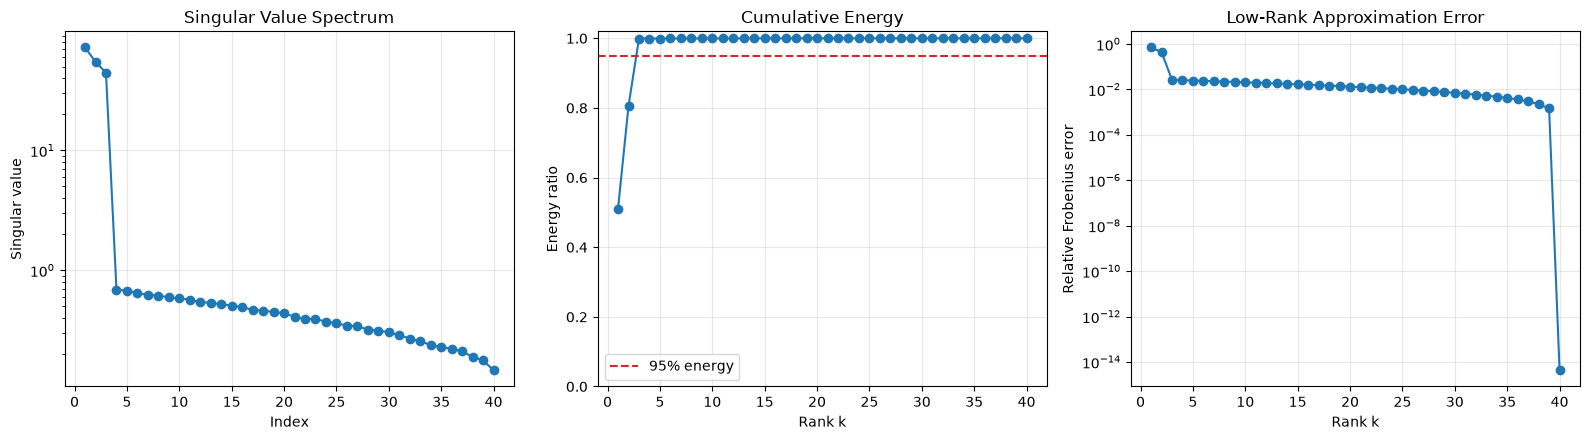

In [10]:
# Build a matrix with a visible low-rank structure plus small noise.
latent_left = rng.normal(size=(80, 3))
latent_right = rng.normal(size=(3, 40))
A_low_rank_data = latent_left @ latent_right + 0.05 * rng.normal(size=(80, 40))

singular_values = np.linalg.svd(A_low_rank_data, compute_uv=False)
cumulative_energy = np.cumsum(singular_values**2) / np.sum(singular_values**2)

ranks = np.arange(1, len(singular_values) + 1)
approximation_errors = np.array([
    np.linalg.norm(A_low_rank_data - rank_k_approximation(A_low_rank_data, k), ord="fro")
    / np.linalg.norm(A_low_rank_data, ord="fro")
    for k in ranks
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].semilogy(ranks, singular_values, "o-")
axes[0].set(title="Singular Value Spectrum", xlabel="Index", ylabel="Singular value")

axes[1].plot(ranks, cumulative_energy, "o-")
axes[1].axhline(0.95, color="tab:red", linestyle="--", label="95% energy")
axes[1].set(title="Cumulative Energy", xlabel="Rank k", ylabel="Energy ratio", ylim=(0, 1.02))
axes[1].legend()

axes[2].semilogy(ranks, np.maximum(approximation_errors, np.finfo(float).tiny), "o-")
axes[2].set(title="Low-Rank Approximation Error", xlabel="Rank k", ylabel="Relative Frobenius error")

for axis in axes:
    axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Principal Component Analysis with SVD

For a data matrix $X$ whose rows are observations and columns are features:

1. center each feature,
2. compute $X_c = U\Sigma V^T$,
3. use columns of $V$ as principal directions,
4. compute scores with $X_cV$ or equivalently $U\Sigma$,
5. use $\sigma_i^2/(N-1)$ as covariance eigenvalues.

Principal directions (rows of Vt):
 [[-0.784116 -0.592389 -0.185036]
 [ 0.034183 -0.338921  0.940194]
 [-0.619672  0.730896  0.286003]]
Explained-variance ratio: [0.960815 0.039185 0.      ]
Total explained-variance ratio: 1.0


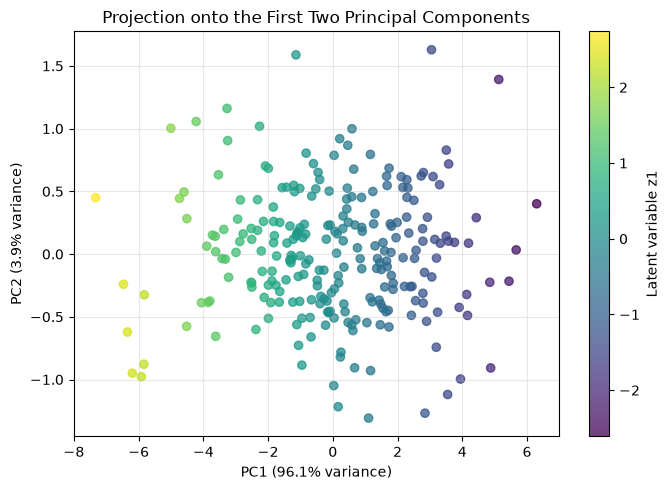

In [11]:
# A correlated three-dimensional dataset
z1 = rng.normal(size=250)
z2 = rng.normal(scale=0.4, size=250)
X = np.column_stack([
    2.0 * z1 + 0.2 * z2,
    1.5 * z1 - 0.3 * z2,
    0.5 * z1 + 1.2 * z2,
])

X_centered = X - X.mean(axis=0)
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)

explained_variance = s_pca**2 / (X.shape[0] - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()
scores = X_centered @ Vt_pca.T

print("Principal directions (rows of Vt):\n", Vt_pca)
print("Explained-variance ratio:", explained_variance_ratio)
print("Total explained-variance ratio:", explained_variance_ratio.sum())

plt.figure(figsize=(7, 5))
plt.scatter(scores[:, 0], scores[:, 1], c=z1, cmap="viridis", alpha=0.75)
plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.1%} variance)")
plt.title("Projection onto the First Two Principal Components")
plt.colorbar(label="Latent variable z1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Numerical Stability and Method Comparison

The eigendecomposition-based method is compared with `np.linalg.svd` on matrices with increasing condition numbers. The recorded metrics are:

- relative reconstruction error,
- relative singular-value error,
- orthogonality error,
- running time.

The experiment is expected to show that forming $A^TA$ squares the condition number, causing the smallest singular values to lose relative accuracy substantially earlier.

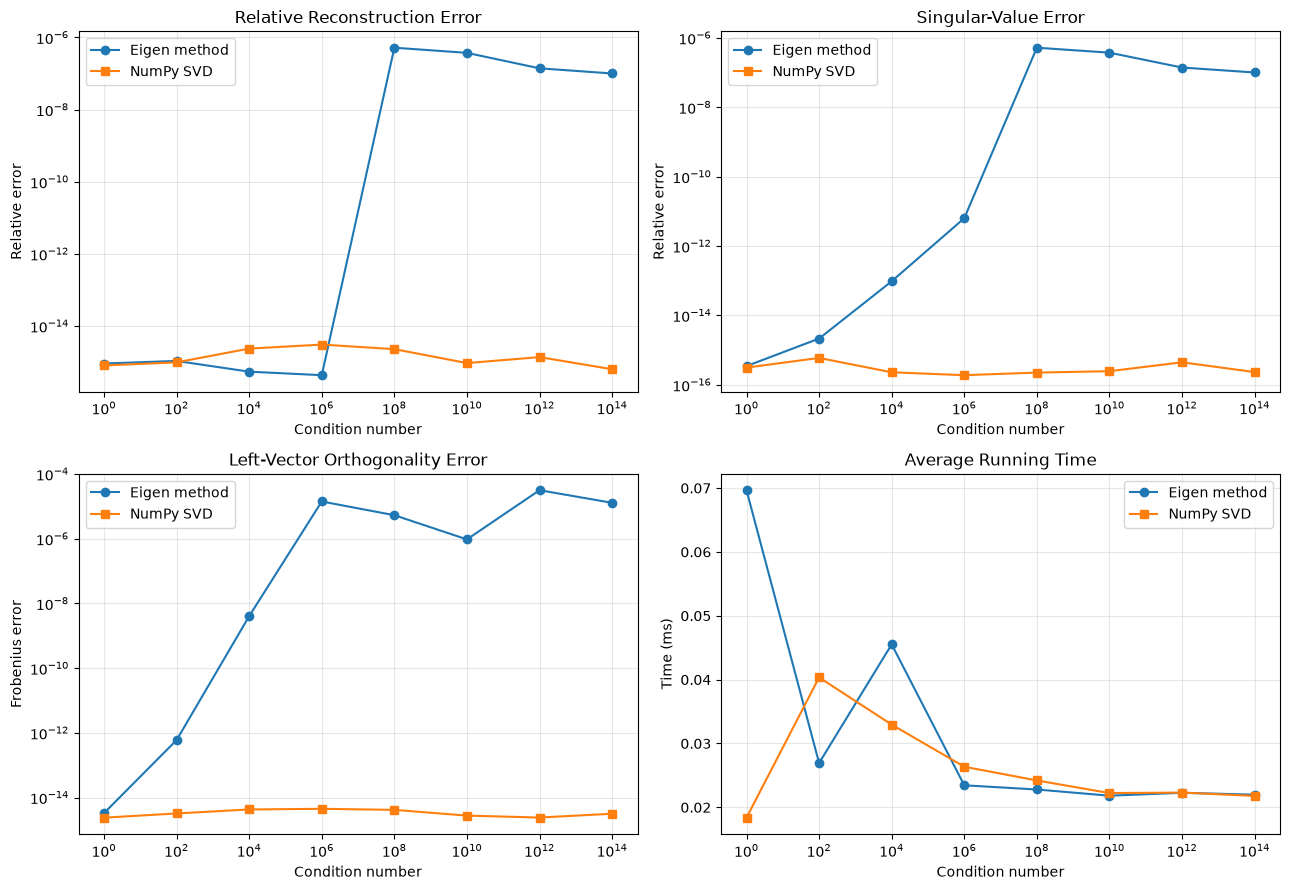

The eigenvalue-based method loses accuracy first in the smallest singular directions.
Reason: forming A.T @ A squares the condition number.


In [12]:
condition_numbers = 10.0 ** np.arange(0, 15, 2)
matrix_shape = (50, 15)
repeats = 10

left_basis, _ = np.linalg.qr(rng.normal(size=matrix_shape))
right_basis, _ = np.linalg.qr(rng.normal(size=(matrix_shape[1], matrix_shape[1])))

metrics = {
    "eigen reconstruction": [], "numpy reconstruction": [],
    "eigen singular values": [], "numpy singular values": [],
    "eigen orthogonality": [], "numpy orthogonality": [],
    "eigen time": [], "numpy time": [],
}

for condition_number in condition_numbers:
    true_s = np.geomspace(1.0, 1.0 / condition_number, matrix_shape[1])
    A_conditioned = left_basis @ np.diag(true_s) @ right_basis.T

    start = time.perf_counter()
    for _ in range(repeats):
        U_eigen, s_eigen, Vt_eigen = svd_via_eigendecomposition(A_conditioned)
    metrics["eigen time"].append((time.perf_counter() - start) / repeats)

    start = time.perf_counter()
    for _ in range(repeats):
        U_numpy, s_numpy, Vt_numpy = np.linalg.svd(A_conditioned, full_matrices=False)
    metrics["numpy time"].append((time.perf_counter() - start) / repeats)

    reconstructed_eigen = U_eigen @ np.diag(s_eigen) @ Vt_eigen
    reconstructed_numpy = U_numpy @ np.diag(s_numpy) @ Vt_numpy
    matrix_norm = np.linalg.norm(A_conditioned, ord="fro")
    metrics["eigen reconstruction"].append(
        np.linalg.norm(A_conditioned - reconstructed_eigen, ord="fro") / matrix_norm
    )
    metrics["numpy reconstruction"].append(
        np.linalg.norm(A_conditioned - reconstructed_numpy, ord="fro") / matrix_norm
    )

    # Pad omitted numerical-zero singular values before comparing with the known spectrum.
    s_eigen_padded = np.zeros_like(true_s)
    s_eigen_padded[:len(s_eigen)] = s_eigen
    metrics["eigen singular values"].append(np.linalg.norm(s_eigen_padded - true_s) / np.linalg.norm(true_s))
    metrics["numpy singular values"].append(np.linalg.norm(s_numpy - true_s) / np.linalg.norm(true_s))

    metrics["eigen orthogonality"].append(
        np.linalg.norm(U_eigen.T @ U_eigen - np.eye(U_eigen.shape[1]), ord="fro")
    )
    metrics["numpy orthogonality"].append(
        np.linalg.norm(U_numpy.T @ U_numpy - np.eye(U_numpy.shape[1]), ord="fro")
    )

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
tiny = np.finfo(float).tiny

comparison_plots = [
    ("reconstruction", "Relative Reconstruction Error", "Relative error"),
    ("singular values", "Singular-Value Error", "Relative error"),
    ("orthogonality", "Left-Vector Orthogonality Error", "Frobenius error"),
]

for axis, (key, title, ylabel) in zip(axes.flat[:3], comparison_plots):
    axis.loglog(condition_numbers, np.maximum(metrics[f"eigen {key}"], tiny), "o-", label="Eigen method")
    axis.loglog(condition_numbers, np.maximum(metrics[f"numpy {key}"], tiny), "s-", label="NumPy SVD")
    axis.set(title=title, xlabel="Condition number", ylabel=ylabel)
    axis.grid(True, which="both", alpha=0.3)
    axis.legend()

axes[1, 1].semilogx(condition_numbers, 1e3 * np.array(metrics["eigen time"]), "o-", label="Eigen method")
axes[1, 1].semilogx(condition_numbers, 1e3 * np.array(metrics["numpy time"]), "s-", label="NumPy SVD")
axes[1, 1].set(title="Average Running Time", xlabel="Condition number", ylabel="Time (ms)")
axes[1, 1].grid(True, which="both", alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("The eigenvalue-based method loses accuracy first in the smallest singular directions.")
print("Reason: forming A.T @ A squares the condition number.")

## 14. Further Extensions

The following extensions would broaden the numerical investigation:

1. Support wide matrices by using $AA^T$ when appropriate.
2. Implement a full SVD, including bases for the null spaces.
3. Study sign ambiguity by comparing singular vectors from two methods.
4. Explore repeated singular values, where individual singular vectors are not unique.
5. Use truncated SVD to compress a grayscale image.
6. Compare SVD least squares with QR and the normal equations from the earlier notebooks.

## 15. Numerical Validation Summary

The executed experiments verify that:

- the custom factors reconstruct full-rank and rank-deficient test matrices within the expected tolerance;
- the retained singular values are nonnegative and sorted in descending order;
- the pseudoinverse agrees with `np.linalg.pinv`;
- the minimum-norm solution agrees with `np.linalg.lstsq`;
- the low-rank approximation error decreases as $k$ increases;
- the PCA explained-variance ratios sum to one;
- the conditioning experiment identifies the accuracy loss caused by forming $A^TA$.